# Agenda
# 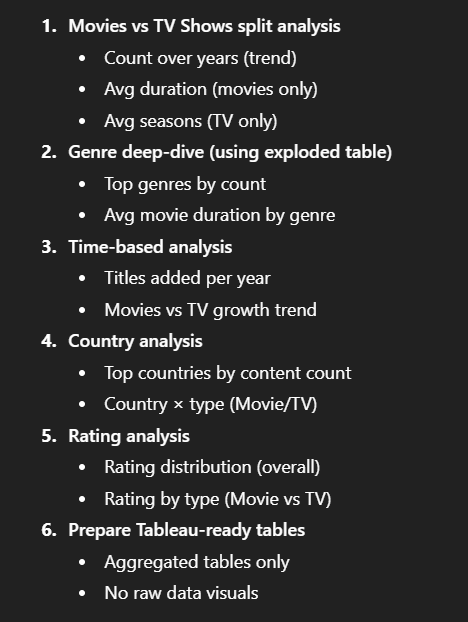

In [1]:

import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.fillna(
    {
        'director': 'Unknown',
        'cast': 'Unknown',
        'country': 'Unknown',
        'date_added': 'Unknown',
        'rating': 'Unknown',
        'duration': 'Unknown'
    }
, inplace = True)

In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce') # coerce - > if not convertible, NaT : missing value

In [8]:
df.columns = df.columns.str.title()

In [9]:
mask = df['Rating'].str.contains(r'\b(min|season)', case=False, na=False)

df.loc[mask, 'Duration'] = df.loc[mask, 'Rating']
df.loc[mask, 'Rating'] = 'Unknown'

df['Duration'] = df['Duration'].replace('nan', 'Unknown')

df[df['Rating'].str.contains('min|season', case=False, na=False)]

/tmp/ipykernel_213/4081085216.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['Rating'].str.contains(r'\b(min|season)', case=False, na=False)


,Show_Id,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Listed_In,Description


#Number of movies released per year

In [34]:
df[df['Type'] == 'Movie']['Release_Year'].value_counts()

,count
Release_Year,
2017,767
2018,767
2016,658
2019,633
2020,517
...,...
1959,1
1963,1
1966,1


#Number of TV show per year

In [11]:
df[df['Type'] == 'TV Show']['Release_Year'].value_counts()

,count
Release_Year,
2020,436
2019,397
2018,380
2021,315
2017,265
2016,244
2015,162
2014,88
2012,64


#Number of Movie per country

In [12]:
df[df['Type']=='Movie']['Country'].value_counts()

,count
Country,
United States,2058
India,893
Unknown,440
United Kingdom,206
Canada,122
...,...
"Germany, Canada, United States",1
"Denmark, United Kingdom, South Africa, Sweden, Belgium",1
"Serbia, South Korea, Slovenia",1


#Number of TV Show per country

In [13]:
df[df['Type']=='TV Show']['Country'].value_counts()

,count
Country,
United States,760
Unknown,391
United Kingdom,213
Japan,169
South Korea,158
...,...
"Ireland, Canada, United States, United Kingdom",1
"Germany, United States, Italy",1
"United Kingdom, United States, Czech Republic",1


#Number of movies per director

In [14]:
df[df['Type']=='Movie']['Director'].value_counts()

,count
Director,
Unknown,188
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,15
...,...
Naoto Amazutsumi,1
Jenny Gage,1
Kaila York,1


#Number of TV shows per director

In [15]:
df[df['Type']=='TV Show']['Director'].value_counts()

,count
Director,
Unknown,2446
Alastair Fothergill,3
Rob Seidenglanz,2
Ken Burns,2
Stan Lathan,2
...,...
Bumpy,1
Michael Samuels,1
Mark Tonderai,1


#Exploding Listed_in column
Separting Listed_in column to separate genres in a separate Dataframe

In [16]:
df_genre = (
    df.assign(genre = df['Listed_In'].str.split(','))
      .explode('genre')
      .assign(genre = lambda x: x['genre'].str.strip())
)
df_genre.head()

,Show_Id,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Listed_In,Description,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",International TV Shows
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",TV Dramas
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Crime TV Shows


#Numeric Values from duration


In [17]:
df['Duration_num'] = df['Duration'].str.extract('(\\d+)').astype(float)

#Avg. duration by Genre of Movie

In [18]:
dur_in_mins = df[df['Type']=='Movie']['Duration_num'].mean().item()
print(str(round(dur_in_mins,1)) + ' minutes')

99.6 minutes


#Avg. Season by Genre of TV Show

In [19]:
seasons = np.ceil(df[df['Type']=='TV Show']['Duration_num'].mean()).item()
print(str(round(seasons)) + ' seasons')

2 seasons


#Number of title by Year (MOVIES)

In [20]:
df[df['Type']=='Movie']['Title'].groupby(df['Release_Year']).count()

,Title
Release_Year,
1942,2
1943,3
1944,3
1945,3
1946,1
...,...
2017,767
2018,767
2019,633


#Number of title by Year (TV SHOWS)

In [21]:
df[df['Type']=='TV Show']['Title'].groupby(df['Release_Year']).count()

,Title
Release_Year,
1925,1
1945,1
1946,1
1963,1
1967,1
1972,1
1974,1
1977,1
1979,1


#Movie titles added per year

In [22]:

added_year = df['Date_Added'].dt.year.astype('Int64')

df[df['Type']=='Movie']['Title'].groupby(added_year).count()

,Title
Date_Added,
2008,1
2009,2
2010,1
2011,13
2012,3
2013,6
2014,19
2015,56
2016,253


# TV Show Titles added per year

In [23]:


df[df['Type']=='TV Show']['Title'].groupby(added_year).count()


,Title
Date_Added,
2008,1
2013,4
2014,4
2015,17
2016,165
2017,325
2018,388
2019,575
2020,594


In [24]:
df_genre


,Show_Id,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Listed_In,Description,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",International TV Shows
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",TV Dramas
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Children & Family Movies
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",Comedies
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Dramas
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,International Movies


# Top Genres by Count

In [25]:
df_genre['Title'].groupby(df_genre['genre']).count().sort_values(ascending=False)

,Title
genre,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


# Top Countries by Content count


In [26]:
df_country = (
    df.assign(country_expl = df['Country'].str.split(','))
      .explode('country_expl')
      .assign(country_expl = lambda x: x['country_expl'].str.strip())
)
df_country.head()
df_country.to_csv('/content/drive/MyDrive/netflix_titles - Country column exploded.csv',index = False)

In [27]:
df_country.head()

,Show_Id,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Listed_In,Description,Duration_num,country_expl
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Unknown
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,India


In [28]:
df_country['Title'].groupby(df_country['country_expl']).count().sort_values(ascending=False)

,Title
country_expl,
United States,3690
India,1046
Unknown,831
United Kingdom,806
Canada,445
...,...
Somalia,1
Samoa,1
Sudan,1


# Top countries with Content Type

In [29]:
df.groupby(['Country','Type']).size().unstack(fill_value=0).sort_values(by=['Movie', 'TV Show'],ascending=False)

Type,Movie,TV Show
Country,,
United States,2058,760
India,893,79
Unknown,440,391
United Kingdom,206,213
Canada,122,59
...,...,...
"United States, Netherlands, Japan, France",0,1
"United States, New Zealand, Japan",0,1
"United States, Poland",0,1


# Movie Rating distrution

In [30]:
df[df['Type']=='Movie']['Title'].groupby(df['Rating']).count().sort_values(ascending=False)


,Title
Rating,
TV-MA,2062
TV-14,1427
R,797
TV-PG,540
PG-13,490
PG,287
TV-Y7,139
TV-Y,131
TV-G,126


# TV show rating distribution

In [31]:
df[df['Type']=='TV Show']['Title'].groupby(df['Rating']).count().sort_values(ascending=False)


,Title
Rating,
TV-MA,1145
TV-14,733
TV-PG,323
TV-Y7,195
TV-Y,176
TV-G,94
NR,5
R,2
Unknown,2


# Saving dataframe to new CSVs

In [32]:
df.to_csv('/content/drive/MyDrive/netflix_titles_cleaned.csv',index = False)
df_genre.to_csv('/content/drive/MyDrive/netflix_titles - Genre column exploded.csv',index = False)